# Indian Equity Portfolio Risk Engine
## Phase 1 — Data Acquisition & Cleaning
**Project:** Portfolio Risk & Optimization Engine | Nifty 50 Universe

**Data source:** Yahoo Finance via `yfinance` (NSE tickers with `.NS` suffix)

**What this notebook does:**
- Downloads 5 years of adjusted close prices for all Nifty 50 stocks
- Cleans missing data and validates quality
- Computes daily log returns
- Saves clean outputs for use in Phase 2

---

In [1]:
# ── Cell 1: Install libraries ──────────────────────────────────────────────
# Colab has most libraries pre-installed but yfinance needs upgrading
!pip install -q yfinance --upgrade
!pip install -q plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.8/137.8 kB 4.2 MB/s eta 0:00:00


In [9]:
# ── Cell 2: Imports ────────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [15]:
# ── Cell 3: Define Nifty 50 universe ──────────────────────────────────────
# Full Nifty 50 constituents with .NS suffix for NSE
# Note: This is the 2024 composition with two ticker corrections:
#   TATAMOTORS.NS → TMPV.NS (post-demerger, Tata Motors Passenger Vehicles)
#   LTIM.NS       → LTM.NS  (rebranded to LTM Limited, Feb 2026)

NIFTY50_TICKERS = [
    'ADANIENT.NS', 'ADANIPORTS.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS',
    'AXISBANK.NS', 'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BAJAJFINSV.NS',
    'BPCL.NS', 'BHARTIARTL.NS', 'BRITANNIA.NS', 'CIPLA.NS',
    'COALINDIA.NS', 'DIVISLAB.NS', 'DRREDDY.NS', 'EICHERMOT.NS',
    'GRASIM.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS',
    'HEROMOTOCO.NS', 'HINDALCO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS',
    'ITC.NS', 'INDUSINDBK.NS', 'INFY.NS', 'JSWSTEEL.NS',
    'KOTAKBANK.NS', 'LT.NS', 'M&M.NS', 'MARUTI.NS',
    'NTPC.NS', 'NESTLEIND.NS', 'ONGC.NS', 'POWERGRID.NS',
    'RELIANCE.NS', 'SBILIFE.NS', 'SBIN.NS', 'SUNPHARMA.NS',
    'TCS.NS', 'TATACONSUM.NS', 'TMPV.NS', 'TATASTEEL.NS',
    'TECHM.NS', 'TITAN.NS', 'ULTRACEMCO.NS', 'UPL.NS',
    'WIPRO.NS', 'LTM.NS'
]

# Benchmark index
BENCHMARK = '^NSEI'

# Date range — 6 years of data
START_DATE = '2019-01-01'
END_DATE   = '2025-12-31'

print(f'Universe: {len(NIFTY50_TICKERS)} stocks')
print(f'Period  : {START_DATE} to {END_DATE}')

Universe: 50 stocks
Period  : 2019-01-01 to 2025-12-31


In [16]:
# ── Cell 4: Download price data ────────────────────────────────────────────
# yfinance downloads adjusted close (splits + dividends accounted for)
# This is the correct price to use for return calculations

print('Downloading Nifty 50 price data... (may take 30-60 seconds)')

raw_prices = yf.download(
    tickers   = NIFTY50_TICKERS,
    start     = START_DATE,
    end       = END_DATE,
    auto_adjust = True,   # gives adjusted prices directly in 'Close'
    progress  = True
)['Close']

print(f'\nDownloaded: {raw_prices.shape[0]} trading days x {raw_prices.shape[1]} stocks')
print(f'Date range: {raw_prices.index[0].date()} to {raw_prices.index[-1].date()}')
raw_prices.tail(3)

[*********************100%***********************]  50 of 50 completed



Downloaded: 1729 trading days x 50 stocks
Date range: 2019-01-01 to 2025-12-30


Ticker,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BHARTIARTL.NS,BPCL.NS,...,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TMPV.NS,ULTRACEMCO.NS,UPL.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-26,2228.903320,1480.859009,7146.512207,2746.500000,1228.199951,8938.703125,2017.599976,1000.000000,2105.399902,355.958862,...,1708.402588,1165.835083,165.702744,3178.342529,1612.300049,3992.000000,358.799988,11794.0,774.049988,259.597809
2025-12-29,2202.215332,1448.296265,7075.106934,2775.399902,1232.000000,8960.890625,2012.099976,998.000000,2081.600098,361.405212,...,1706.117310,1185.171387,168.818497,3150.725586,1612.400024,3983.699951,358.600006,11799.0,770.950012,257.589661
2025-12-30,2213.710205,1455.067627,6980.732422,2758.300049,1246.000000,9153.184570,2026.400024,989.299988,2099.800049,359.362823,...,1709.098022,1169.107422,172.247772,3146.171631,1604.599976,3974.100098,361.750000,11705.0,787.349976,257.014526


In [17]:
# ── Cell 5: Download benchmark (Nifty 50 index) ───────────────────────────

benchmark_raw = yf.download(
    BENCHMARK,
    start       = START_DATE,
    end         = END_DATE,
    auto_adjust = True,
    progress    = False
)['Close']

benchmark_raw.name = 'NIFTY50'
print(f'Benchmark downloaded: {len(benchmark_raw)} trading days')
benchmark_raw.tail(3)

Benchmark downloaded: 1726 trading days


Ticker,^NSEI
Date,
2025-12-26,26042.300781
2025-12-29,25942.099609
2025-12-30,25938.849609


In [18]:
# ── Cell 6: Data quality audit ─────────────────────────────────────────────
# Before cleaning, understand what we're working with

missing = raw_prices.isnull().sum()
missing_pct = (missing / len(raw_prices) * 100).round(2)

quality_report = pd.DataFrame({
    'Missing days' : missing,
    'Missing %'    : missing_pct,
    'First valid'  : raw_prices.apply(lambda c: c.first_valid_index()),
    'Last valid'   : raw_prices.apply(lambda c: c.last_valid_index())
}).sort_values('Missing %', ascending=False)

print('=== Data Quality Report ===')
print(f'Stocks with >5% missing: {(missing_pct > 5).sum()}')
print(f'Stocks with 0% missing : {(missing_pct == 0).sum()}')
print()
print(quality_report[quality_report['Missing %'] > 0].to_string())

=== Data Quality Report ===
Stocks with >5% missing: 0
Stocks with 0% missing : 50

Empty DataFrame
Columns: [Missing days, Missing %, First valid, Last valid]
Index: []


In [19]:
# ── Cell 7: Clean the data ─────────────────────────────────────────────────
# Strategy:
#   1. Forward-fill gaps up to 3 days (handles NSE holidays + weekends)
#   2. Drop any stock still missing >5% after forward fill
#   3. Drop rows (dates) where more than 10% of stocks have no data

# Step 1: Forward fill (max 3 consecutive days)
prices_ffill = raw_prices.ffill(limit=3)

# Step 2: Drop stocks with too many remaining missing values
remaining_missing_pct = prices_ffill.isnull().sum() / len(prices_ffill) * 100
stocks_to_drop = remaining_missing_pct[remaining_missing_pct > 5].index.tolist()

if stocks_to_drop:
    print(f'Dropping {len(stocks_to_drop)} stocks with >5% missing: {stocks_to_drop}')
    prices_clean = prices_ffill.drop(columns=stocks_to_drop)
else:
    prices_clean = prices_ffill
    print('No stocks dropped — all within acceptable missing threshold.')

# Step 3: Drop rows where >10% of stocks are missing
row_missing_pct = prices_clean.isnull().mean(axis=1)
prices_clean = prices_clean[row_missing_pct <= 0.10]

# Final fill for any remaining isolated NaNs
prices_clean = prices_clean.ffill().bfill()

print(f'\nFinal clean dataset: {prices_clean.shape[0]} days x {prices_clean.shape[1]} stocks')
print(f'Remaining NaNs: {prices_clean.isnull().sum().sum()}')

No stocks dropped — all within acceptable missing threshold.

Final clean dataset: 1729 days x 50 stocks
Remaining NaNs: 0


In [21]:
# ── Cell 8: Compute daily log returns ─────────────────────────────────────
# WHY log returns?
#   - Time-additive: weekly return = sum of daily log returns
#   - More normally distributed than simple returns
#   - Better for portfolio math and risk calculations
#
# Simple return  = (P_t / P_{t-1}) - 1
# Log return     = ln(P_t / P_{t-1})

log_returns = np.log(prices_clean / prices_clean.shift(1)).dropna()

# Also compute simple returns for intuitive metrics
simple_returns = prices_clean.pct_change().dropna()

# Benchmark returns
benchmark_returns = np.log(benchmark_raw / benchmark_raw.shift(1)).dropna()

print(f'Returns matrix shape: {log_returns.shape}')
print(f'\nSample — mean daily log return (top 5 stocks):')
print((log_returns.mean() * 100).sort_values(ascending=False).head(5).round(4).to_string())
print(f'\nNifty 50 mean daily log return: {float(benchmark_returns.mean())*100:.4f}%')

Returns matrix shape: (1728, 50)

Sample — mean daily log return (top 5 stocks):
Ticker
ADANIENT.NS      0.1538
BHARTIARTL.NS    0.1165
TATACONSUM.NS    0.1007
APOLLOHOSP.NS    0.1000
M&M.NS           0.0937

Nifty 50 mean daily log return: 0.0508%


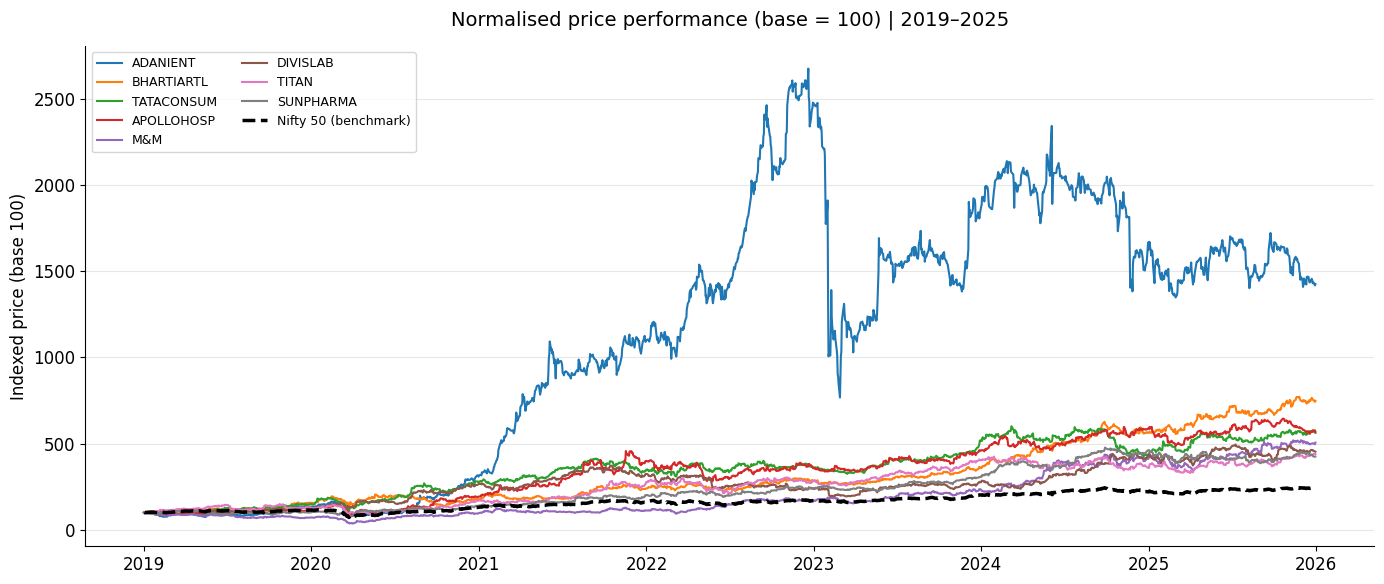

Chart saved as normalised_prices.png


In [23]:
# ── Cell 9: Visualise — price normalised to 100 (top 8 stocks) ────────────
# Normalising to 100 lets us compare stocks with different price scales

top8 = log_returns.mean().sort_values(ascending=False).head(8).index.tolist()
norm_prices = (prices_clean[top8] / prices_clean[top8].iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))
for col in top8:
    ax.plot(norm_prices.index, norm_prices[col], linewidth=1.5, label=col.replace('.NS',''))

# Add Nifty 50 benchmark
norm_bench = (benchmark_raw / benchmark_raw.iloc[0]) * 100
ax.plot(norm_bench.index, norm_bench, color='black', linewidth=2.5,
        linestyle='--', label='Nifty 50 (benchmark)')

ax.set_title('Normalised price performance (base = 100) | 2019–2025', fontsize=14, pad=15)
ax.set_ylabel('Indexed price (base 100)')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('normalised_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as normalised_prices.png')

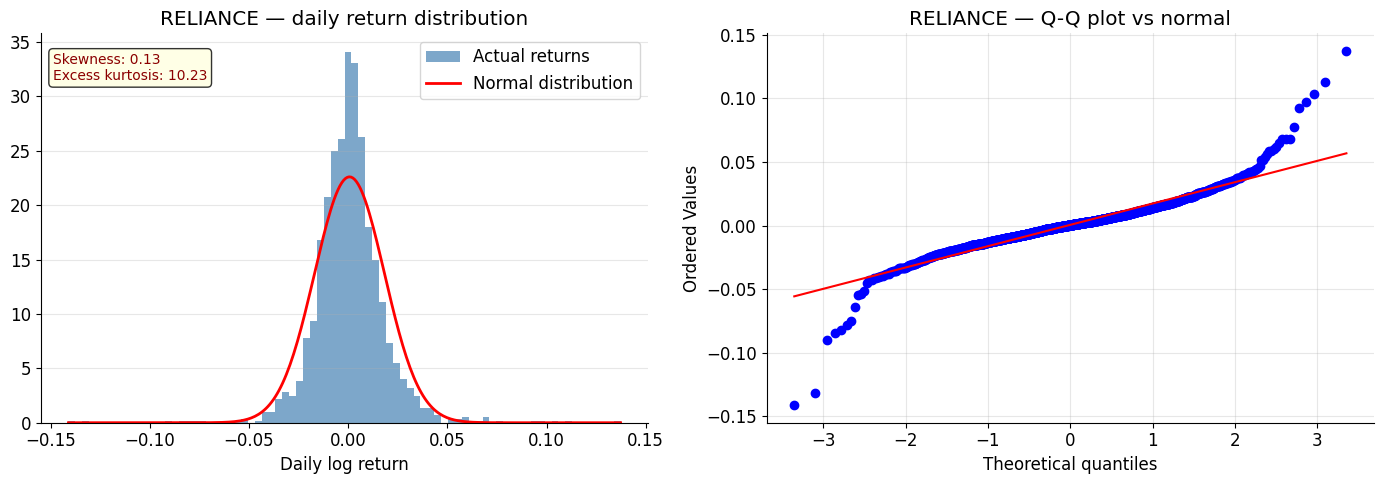


Note: Fat tails visible in Q-Q plot — important context for VaR in Phase 2


In [24]:
# ── Cell 10: Visualise — return distribution for one stock ────────────────
# Checking normality is important for risk models like Parametric VaR
# (Phase 2 will use this assumption)

from scipy import stats

stock = 'RELIANCE.NS'
r = log_returns[stock].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with normal overlay
axes[0].hist(r, bins=80, density=True, color='steelblue', alpha=0.7, label='Actual returns')
x_range = np.linspace(r.min(), r.max(), 300)
axes[0].plot(x_range, stats.norm.pdf(x_range, r.mean(), r.std()),
             'r-', linewidth=2, label='Normal distribution')
axes[0].set_title(f'{stock.replace(".NS","")} — daily return distribution')
axes[0].set_xlabel('Daily log return')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# QQ plot
stats.probplot(r, dist='norm', plot=axes[1])
axes[1].set_title(f'{stock.replace(".NS","")} — Q-Q plot vs normal')
axes[1].grid(alpha=0.3)

# Skewness & kurtosis annotation
skew = r.skew()
kurt = r.kurtosis()
axes[0].annotate(f'Skewness: {skew:.2f}\nExcess kurtosis: {kurt:.2f}',
                 xy=(0.02, 0.95), xycoords='axes fraction', va='top',
                 fontsize=10, color='darkred',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nNote: Fat tails visible in Q-Q plot — important context for VaR in Phase 2')

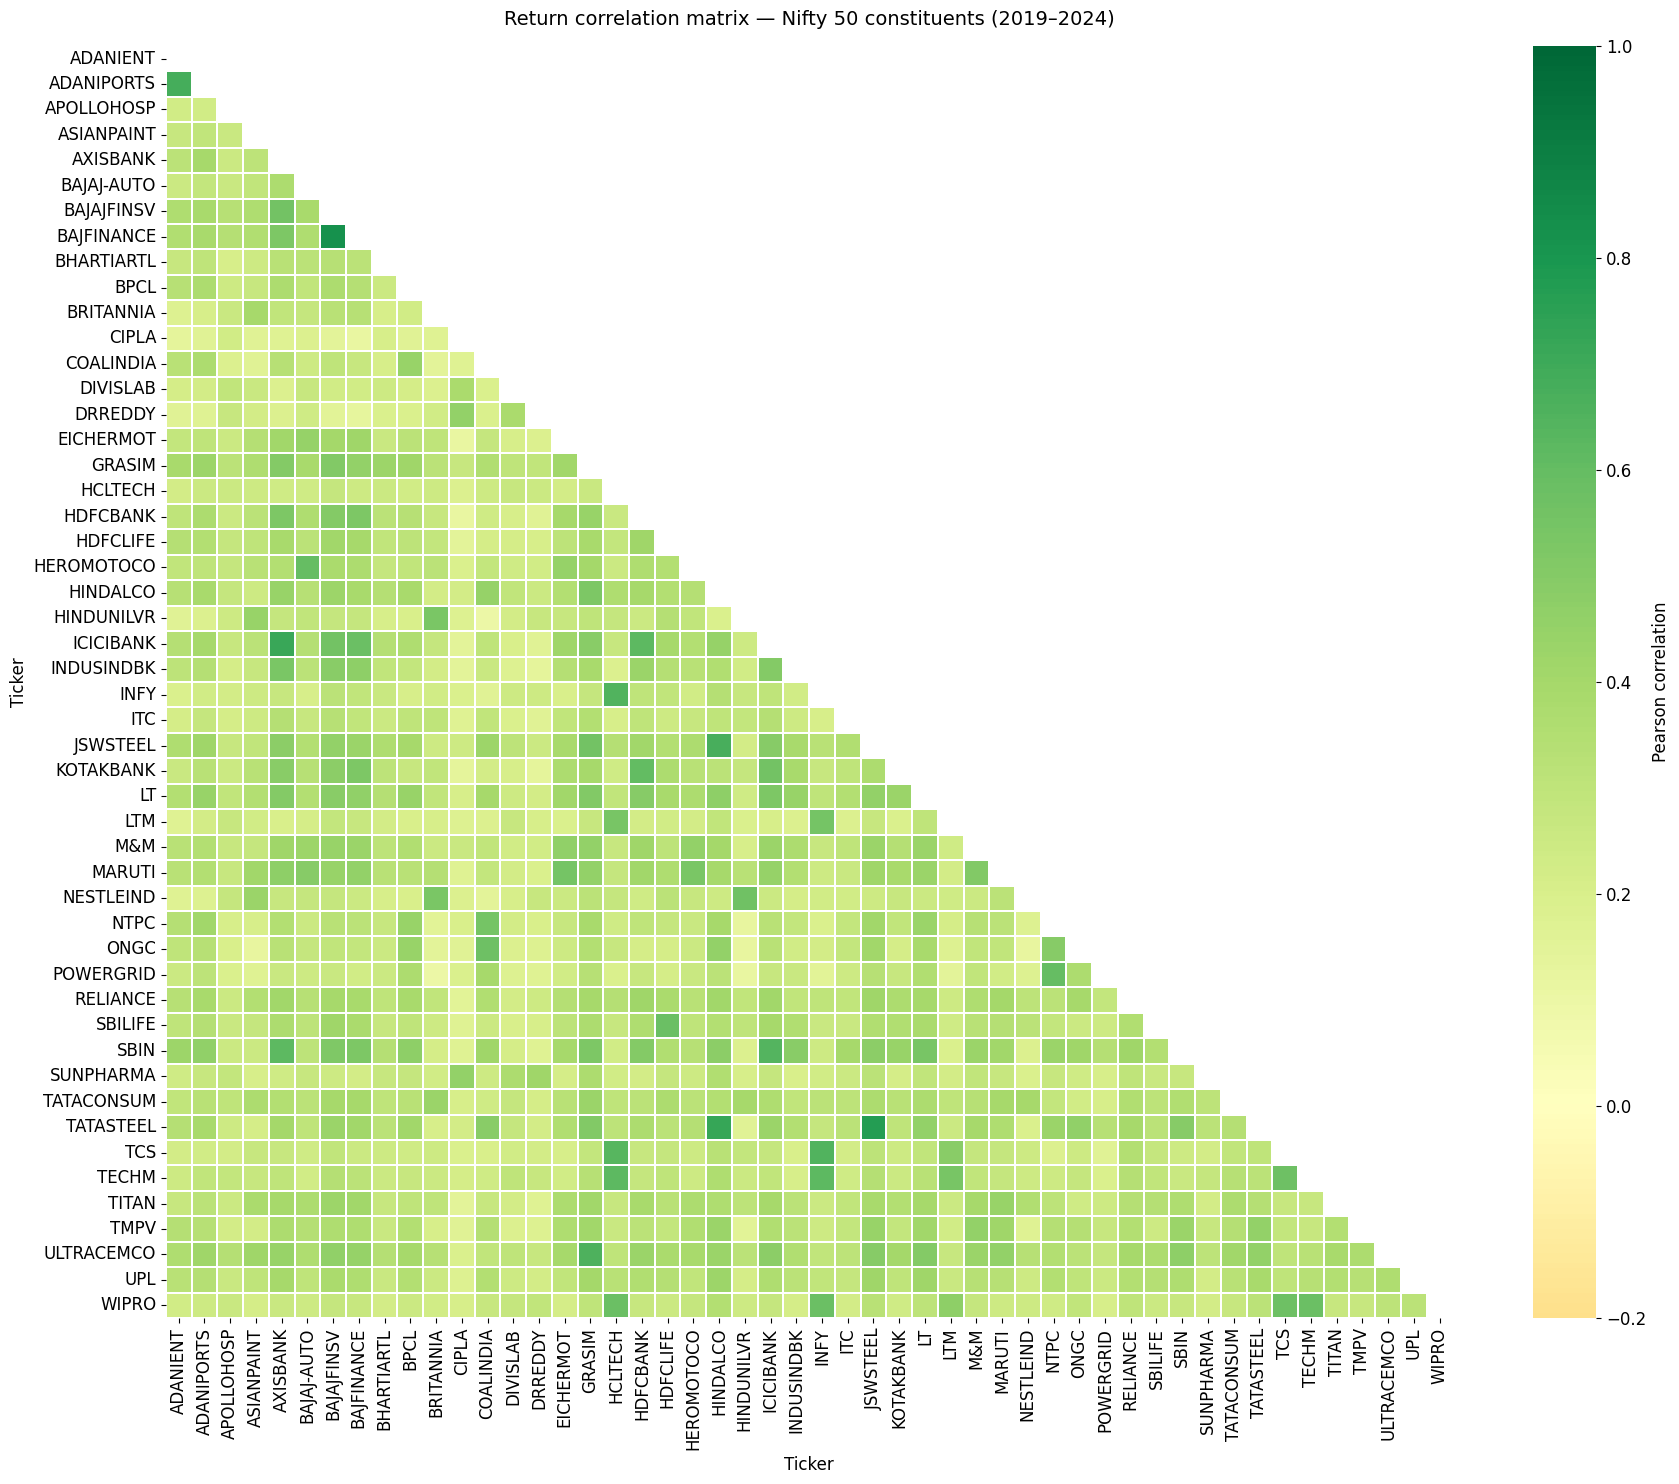

Average pairwise correlation: 0.313
(Lower = better diversification potential)


In [25]:
# ── Cell 11: Correlation heatmap ───────────────────────────────────────────
# High correlation between stocks reduces diversification benefit
# This will feed directly into Phase 3 covariance matrix

corr_matrix = log_returns.corr()

# Shorten ticker names for display
short_names = {t: t.replace('.NS','') for t in corr_matrix.columns}
corr_display = corr_matrix.rename(index=short_names, columns=short_names)

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_display, dtype=bool))  # Hide upper triangle
sns.heatmap(
    corr_display,
    mask=mask,
    annot=False,
    cmap='RdYlGn',
    center=0,
    vmin=-0.2, vmax=1.0,
    linewidths=0.3,
    cbar_kws={'label': 'Pearson correlation'},
    ax=ax
)
ax.set_title('Return correlation matrix — Nifty 50 constituents (2019–2024)',
             fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Report average correlation
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
avg_corr = upper_tri.stack().mean()
print(f'Average pairwise correlation: {avg_corr:.3f}')
print('(Lower = better diversification potential)')

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
# ── Cell 12: Save Phase 1 outputs ─────────────────────────────────────────
# Save to Google Drive for persistence across Colab sessions
# Run this cell AFTER mounting Drive (see comment below)

# To mount Google Drive, run this first:
from google.colab import drive
drive.mount('/content/drive')
SAVE_PATH = '/content/drive/MyDrive/portfolio_project/'

# For now, saving locally (will be lost on session restart)
import os
#SAVE_PATH = '/content/portfolio_data/'
os.makedirs(SAVE_PATH, exist_ok=True)

prices_clean.to_csv(SAVE_PATH + 'prices_clean.csv')
log_returns.to_csv(SAVE_PATH + 'log_returns.csv')
simple_returns.to_csv(SAVE_PATH + 'simple_returns.csv')
benchmark_returns.to_csv(SAVE_PATH + 'benchmark_returns.csv')
corr_matrix.to_csv(SAVE_PATH + 'correlation_matrix.csv')

print('Phase 1 outputs saved:')
for f in os.listdir(SAVE_PATH):
    size = os.path.getsize(SAVE_PATH + f) / 1024
    print(f'  {f:35s} {size:.1f} KB')
print('\nPhase 1 complete. Proceed to Phase 2.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Phase 1 outputs saved:
  prices_clean.csv                    1495.9 KB
  log_returns.csv                     1825.8 KB
  simple_returns.csv                  1825.7 KB
  benchmark_returns.csv               55.0 KB
  correlation_matrix.csv              47.8 KB

Phase 1 complete. Proceed to Phase 2.


---
## Phase 2 — Risk Analytics

**What this section covers:**
- Rolling & EWMA volatility
- Value at Risk — Historical and Parametric (two methods interviewers ask about)
- Maximum Drawdown
- Sharpe Ratio and Sortino Ratio
- Full risk metrics table for all stocks

---

In [28]:
# ── Cell 13: Annualisation constants ──────────────────────────────────────
# NSE trades ~250 days/year (accounting for Indian market holidays)
# All annual metrics = daily metric × sqrt(250) for vol, × 250 for returns

TRADING_DAYS = 250
RISK_FREE_RATE_ANNUAL = 0.065  # RBI repo rate approximation (6.5%)
RISK_FREE_DAILY = RISK_FREE_RATE_ANNUAL / TRADING_DAYS

print(f'Trading days/year : {TRADING_DAYS}')
print(f'Risk-free rate    : {RISK_FREE_RATE_ANNUAL*100:.1f}% annual / {RISK_FREE_DAILY*100:.4f}% daily')
print('(Using RBI repo rate as proxy for risk-free rate — standard for Indian market)')

Trading days/year : 250
Risk-free rate    : 6.5% annual / 0.0260% daily
(Using RBI repo rate as proxy for risk-free rate — standard for Indian market)


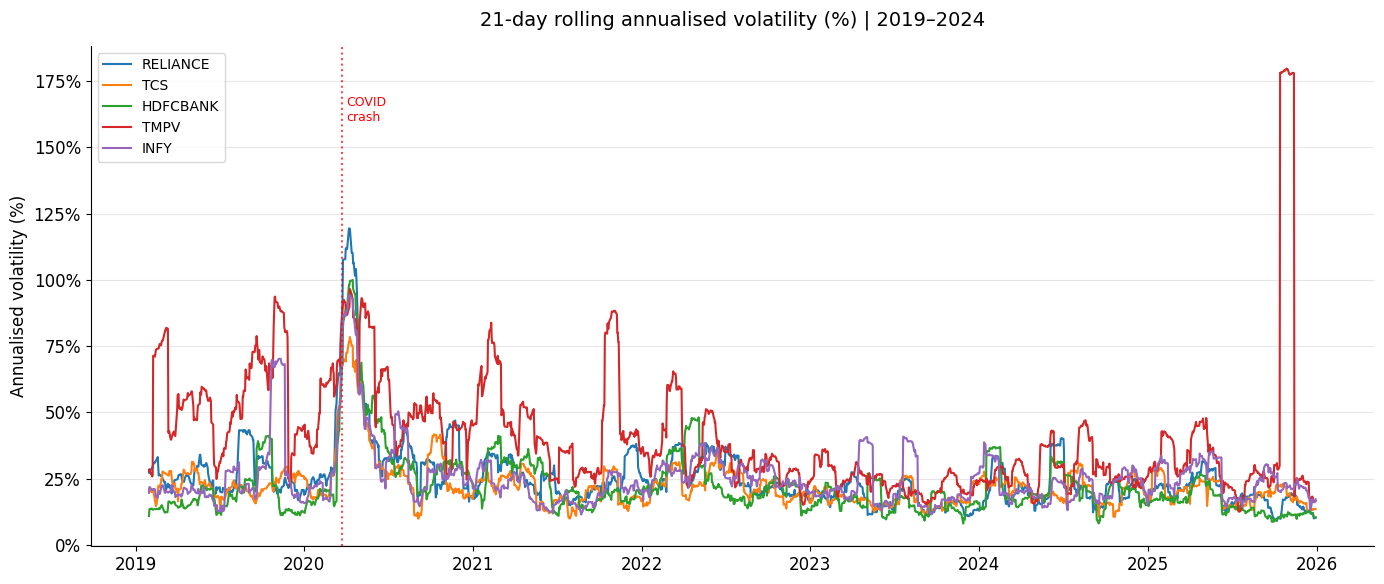

In [30]:
# ── Cell 14: Rolling volatility ────────────────────────────────────────────
# Rolling vol = std dev of returns over a rolling window, annualised
# 21-day window ≈ 1 month of trading days
# 63-day window ≈ 1 quarter
#
# WHY this matters in interviews:
# Volatility is not constant. Rolling vol shows how risk changes over time.
# You can see vol spikes during COVID (March 2020), Russia-Ukraine, etc.

ROLL_WINDOW = 21  # 1-month rolling window

rolling_vol = log_returns.rolling(ROLL_WINDOW).std() * np.sqrt(TRADING_DAYS)

# Plot for 5 major stocks
plot_stocks = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'TMPV.NS', 'INFY.NS']

fig, ax = plt.subplots(figsize=(14, 6))
for stock in plot_stocks:
    ax.plot(rolling_vol.index, rolling_vol[stock] * 100,
            linewidth=1.5, label=stock.replace('.NS',''))

# Annotate COVID crash
ax.axvline(pd.Timestamp('2020-03-23'), color='red', linestyle=':', alpha=0.7)
ax.text(pd.Timestamp('2020-04-01'), ax.get_ylim()[1]*0.85, 'COVID\ncrash',
        fontsize=9, color='red')

ax.set_title(f'{ROLL_WINDOW}-day rolling annualised volatility (%) | 2019–2024', fontsize=14, pad=15)
ax.set_ylabel('Annualised volatility (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

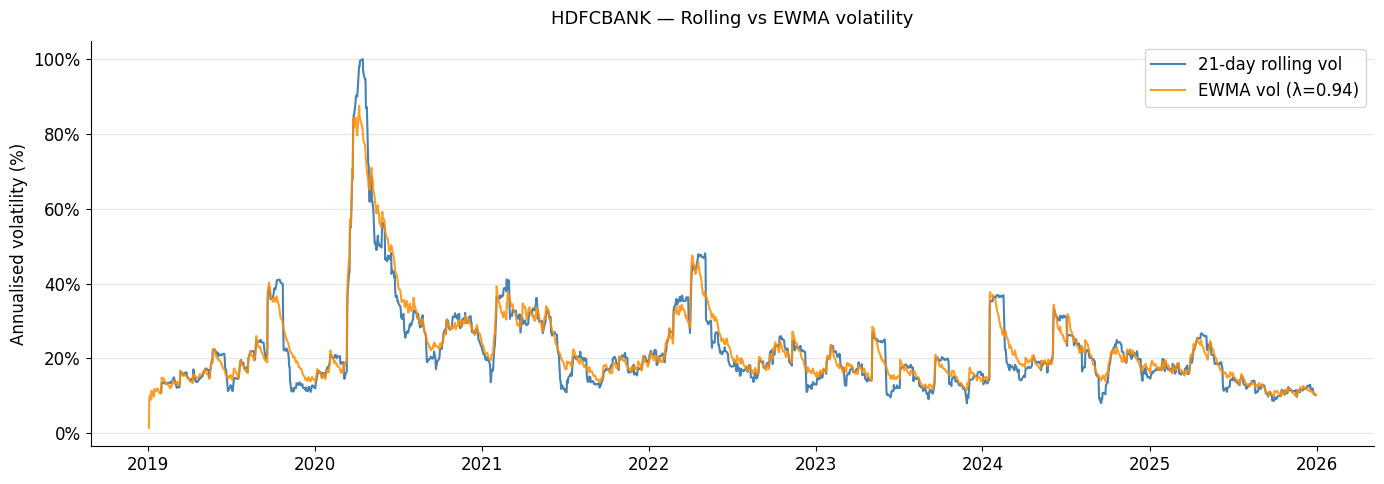

EWMA reacts faster to volatility spikes — preferred by risk desks in practice


In [31]:
# ── Cell 15: EWMA volatility (RiskMetrics model) ──────────────────────────
# Exponentially Weighted Moving Average gives more weight to recent returns
# Lambda (decay factor) = 0.94 is the J.P. Morgan RiskMetrics standard
#
# Formula: σ²_t = λ·σ²_{t-1} + (1-λ)·r²_{t-1}
# This captures: recent bad news matters more than old bad news

LAMBDA = 0.94

ewma_vol = log_returns.ewm(span=(2/(1-LAMBDA)-1), adjust=False).std() * np.sqrt(TRADING_DAYS)

# Compare rolling vs EWMA for one stock
stock = 'HDFCBANK.NS'
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_vol[stock]*100, label=f'{ROLL_WINDOW}-day rolling vol',
        linewidth=1.5, color='steelblue')
ax.plot(ewma_vol[stock]*100, label=f'EWMA vol (λ={LAMBDA})',
        linewidth=1.5, color='darkorange', alpha=0.85)
ax.set_title(f'{stock.replace(".NS","")} — Rolling vs EWMA volatility', fontsize=13, pad=12)
ax.set_ylabel('Annualised volatility (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ewma_vs_rolling_vol.png', dpi=150, bbox_inches='tight')
plt.show()
print('EWMA reacts faster to volatility spikes — preferred by risk desks in practice')

In [32]:
# ── Cell 16: Value at Risk — Historical simulation ─────────────────────────
# Historical VaR: "What was the worst X% of days in our actual history?"
# No distributional assumption — uses empirical return distribution
#
# VaR(95%) = the return at the 5th percentile of the distribution
# Interpretation: "On 95% of days, the loss was better than this number"
#                 "On 5% of days, the loss was WORSE than this number"
#
# Convention: VaR is reported as a POSITIVE number (magnitude of loss)

CONFIDENCE_LEVELS = [0.95, 0.99]

def historical_var(returns_series, confidence=0.95):
    """Returns VaR as a positive number representing potential loss."""
    return -np.percentile(returns_series.dropna(), (1 - confidence) * 100)

def historical_cvar(returns_series, confidence=0.95):
    """Conditional VaR (Expected Shortfall) — average of losses beyond VaR."""
    var = historical_var(returns_series, confidence)
    return -returns_series[returns_series < -var].mean()

# Compute for all stocks
var_results = {}
for cl in CONFIDENCE_LEVELS:
    var_results[f'Hist_VaR_{int(cl*100)}'] = log_returns.apply(
        lambda col: historical_var(col, cl) * 100)
    var_results[f'Hist_CVaR_{int(cl*100)}'] = log_returns.apply(
        lambda col: historical_cvar(col, cl) * 100)

var_df = pd.DataFrame(var_results)

# Show top 10 riskiest stocks by 99% VaR
print('Top 10 riskiest stocks (Historical 99% VaR — daily % loss):')
print(var_df['Hist_VaR_99'].sort_values(ascending=False).head(10).round(3).to_string())

Top 10 riskiest stocks (Historical 99% VaR — daily % loss):
Ticker
ADANIENT.NS      8.351
INDUSINDBK.NS    8.151
TMPV.NS          7.567
BAJFINANCE.NS    7.216
ADANIPORTS.NS    7.182
HINDALCO.NS      6.525
UPL.NS           6.520
JSWSTEEL.NS      6.385
TATASTEEL.NS     6.376
M&M.NS           6.095


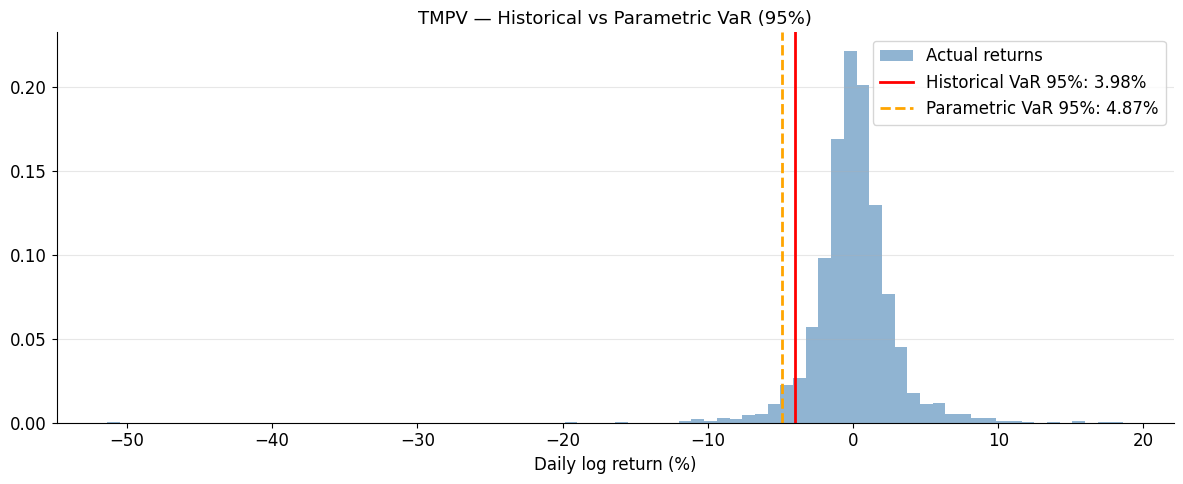

Historical VaR > Parametric VaR = fat tails — historical method more conservative


In [34]:
# ── Cell 17: Value at Risk — Parametric (Gaussian) ────────────────────────
# Parametric VaR: assumes returns follow a normal distribution
# Uses mean and std dev with a z-score
#
# VaR(95%) = μ - 1.645·σ
# VaR(99%) = μ - 2.326·σ
#
# Faster to compute, but underestimates risk when returns have fat tails
# (Which you saw in Cell 10 — they usually do!)

from scipy.stats import norm

Z_SCORES = {0.95: norm.ppf(0.05), 0.99: norm.ppf(0.01)}  # Negative z-scores

def parametric_var(returns_series, confidence=0.95):
    mu = returns_series.mean()
    sigma = returns_series.std()
    return -(mu + Z_SCORES[confidence] * sigma)

for cl in CONFIDENCE_LEVELS:
    var_df[f'Para_VaR_{int(cl*100)}'] = log_returns.apply(
        lambda col: parametric_var(col, cl) * 100)

# Compare historical vs parametric for one stock
stock = 'TMPV.NS'
r = log_returns[stock].dropna() * 100

h_var95 = historical_var(log_returns[stock]) * 100
p_var95 = parametric_var(log_returns[stock]) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(r, bins=80, density=True, color='steelblue', alpha=0.6, label='Actual returns')
ax.axvline(-h_var95, color='red',    linewidth=2, label=f'Historical VaR 95%: {h_var95:.2f}%')
ax.axvline(-p_var95, color='orange', linewidth=2, linestyle='--',
           label=f'Parametric VaR 95%: {p_var95:.2f}%')
ax.set_title(f'{stock.replace(".NS","")} — Historical vs Parametric VaR (95%)', fontsize=13)
ax.set_xlabel('Daily log return (%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('var_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Historical VaR > Parametric VaR = fat tails — historical method more conservative')

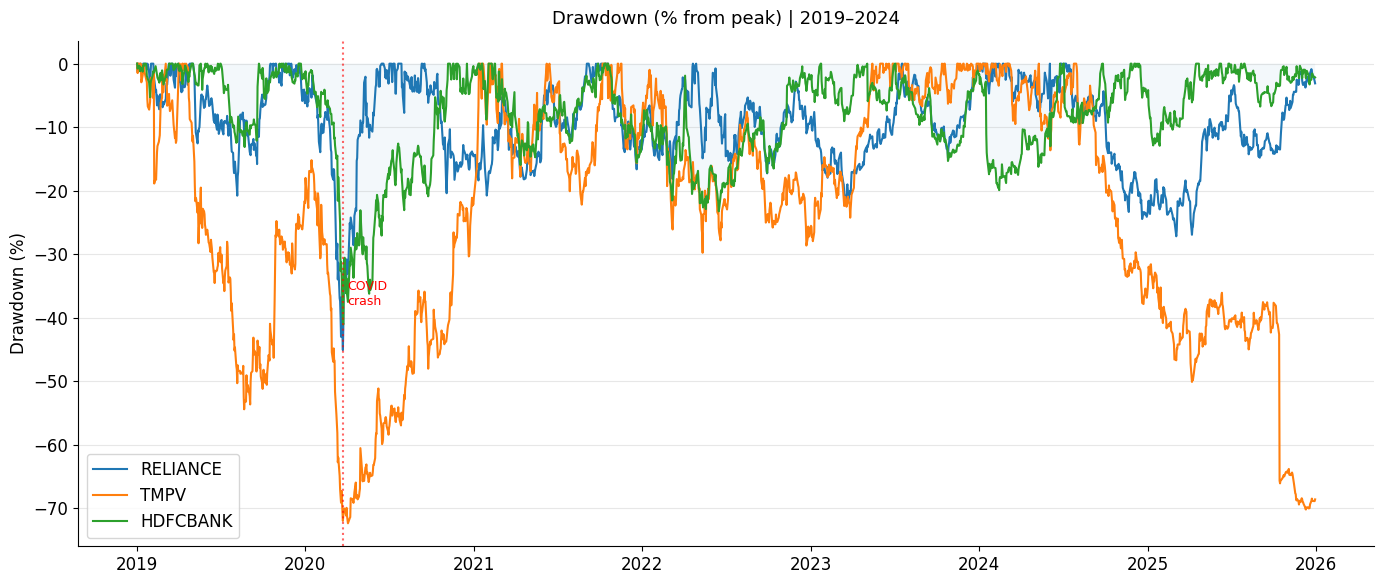

In [35]:
# ── Cell 18: Maximum Drawdown ──────────────────────────────────────────────
# Max Drawdown = largest peak-to-trough decline in portfolio value
# Formula: MDD = (Trough - Peak) / Peak
# Answers: "What's the worst loss an investor could have experienced?"
# Very commonly asked in fund management interviews

def max_drawdown(price_series):
    """Returns max drawdown as a positive percentage."""
    cumulative = (1 + price_series.pct_change()).cumprod()
    rolling_peak = cumulative.cummax()
    drawdown = (cumulative - rolling_peak) / rolling_peak
    return abs(drawdown.min()) * 100

def plot_drawdown(ticker):
    price = prices_clean[ticker]
    cumulative = (1 + price.pct_change()).cumprod()
    rolling_peak = cumulative.cummax()
    drawdown = (cumulative - rolling_peak) / rolling_peak * 100
    return drawdown

mdd_series = prices_clean.apply(max_drawdown)

# Plot drawdown for 3 stocks
stocks_dd = ['RELIANCE.NS', 'TMPV.NS', 'HDFCBANK.NS']
fig, ax = plt.subplots(figsize=(14, 6))
for s in stocks_dd:
    dd = plot_drawdown(s)
    ax.plot(dd.index, dd, linewidth=1.5, label=s.replace('.NS',''))
ax.fill_between(dd.index, dd, 0, alpha=0.05)
ax.set_title('Drawdown (% from peak) | 2019–2024', fontsize=13, pad=12)
ax.set_ylabel('Drawdown (%)')
ax.axvline(pd.Timestamp('2020-03-23'), color='red', linestyle=':', alpha=0.6)
ax.text(pd.Timestamp('2020-04-01'), ax.get_ylim()[0]*0.5, 'COVID\ncrash',
        fontsize=9, color='red')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('drawdown_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# ── Cell 19: Sharpe & Sortino Ratios ──────────────────────────────────────
# Sharpe  = (Annual return - Risk free rate) / Annual volatility
#           Risk-adjusted return using TOTAL volatility (up + down moves)
#
# Sortino = (Annual return - Risk free rate) / Downside deviation
#           Better metric: only penalises for DOWNSIDE volatility
#           Upside volatility is not a risk — it's a reward!
#
# Sharpe > 1 is generally considered good
# Sortino > 1.5 is generally considered good

def sharpe_ratio(returns_series, rf_daily=RISK_FREE_DAILY, periods=TRADING_DAYS):
    excess = returns_series - rf_daily
    return (excess.mean() / excess.std()) * np.sqrt(periods)

def sortino_ratio(returns_series, rf_daily=RISK_FREE_DAILY, periods=TRADING_DAYS):
    excess = returns_series - rf_daily
    downside_returns = excess[excess < 0]
    downside_std = np.sqrt((downside_returns**2).mean()) * np.sqrt(periods)
    annual_excess = excess.mean() * periods
    return annual_excess / downside_std if downside_std != 0 else np.nan

sharpe_series  = log_returns.apply(sharpe_ratio)
sortino_series = log_returns.apply(sortino_ratio)

print('Top 10 stocks by Sharpe Ratio:')
print(sharpe_series.sort_values(ascending=False).head(10).round(3).to_string())
print()
print('Top 10 stocks by Sortino Ratio:')
print(sortino_series.sort_values(ascending=False).head(10).round(3).to_string())

Top 10 stocks by Sharpe Ratio:
Ticker
BHARTIARTL.NS    0.799
TATACONSUM.NS    0.659
ADANIENT.NS      0.625
APOLLOHOSP.NS    0.580
SUNPHARMA.NS     0.558
DIVISLAB.NS      0.538
HCLTECH.NS       0.537
BAJAJ-AUTO.NS    0.537
TITAN.NS         0.535
M&M.NS           0.525

Top 10 stocks by Sortino Ratio:
Ticker
BHARTIARTL.NS    0.854
TATACONSUM.NS    0.690
APOLLOHOSP.NS    0.619
ADANIENT.NS      0.602
SUNPHARMA.NS     0.573
HCLTECH.NS       0.549
M&M.NS           0.537
DIVISLAB.NS      0.537
BAJAJ-AUTO.NS    0.537
TITAN.NS         0.531


In [37]:
# ── Cell 20: Master risk metrics table ────────────────────────────────────
# This is the key output of Phase 2
# One row per stock, all risk metrics in columns

annual_return = log_returns.mean() * TRADING_DAYS * 100
annual_vol    = log_returns.std() * np.sqrt(TRADING_DAYS) * 100

risk_metrics = pd.DataFrame({
    'Annual return (%)'   : annual_return.round(2),
    'Annual vol (%)'      : annual_vol.round(2),
    'Sharpe ratio'        : sharpe_series.round(3),
    'Sortino ratio'       : sortino_series.round(3),
    'Max drawdown (%)'    : mdd_series.round(2),
    'Hist VaR 95% (%)'    : var_df['Hist_VaR_95'].round(3),
    'Hist VaR 99% (%)'    : var_df['Hist_VaR_99'].round(3),
    'Hist CVaR 95% (%)'   : var_df['Hist_CVaR_95'].round(3),
    'Para VaR 95% (%)'    : var_df['Para_VaR_95'].round(3),
})

risk_metrics.index = risk_metrics.index.str.replace('.NS', '', regex=False)
risk_metrics = risk_metrics.sort_values('Sharpe ratio', ascending=False)

print('=== Master Risk Metrics Table (sorted by Sharpe Ratio) ===')
print(risk_metrics.to_string())

=== Master Risk Metrics Table (sorted by Sharpe Ratio) ===
            Annual return (%)  Annual vol (%)  Sharpe ratio  Sortino ratio  Max drawdown (%)  Hist VaR 95% (%)  Hist VaR 99% (%)  Hist CVaR 95% (%)  Para VaR 95% (%)
Ticker                                                                                                                                                               
BHARTIARTL              29.13           28.32         0.799          0.854             33.35             2.587             4.504              3.867             2.829
TATACONSUM              25.17           28.31         0.659          0.690             42.93             2.398             4.786              3.890             2.845
ADANIENT                38.45           51.07         0.625          0.602             71.35             3.803             8.351              7.399             5.160
APOLLOHOSP              24.99           31.86         0.580          0.619             39.42             2.714 

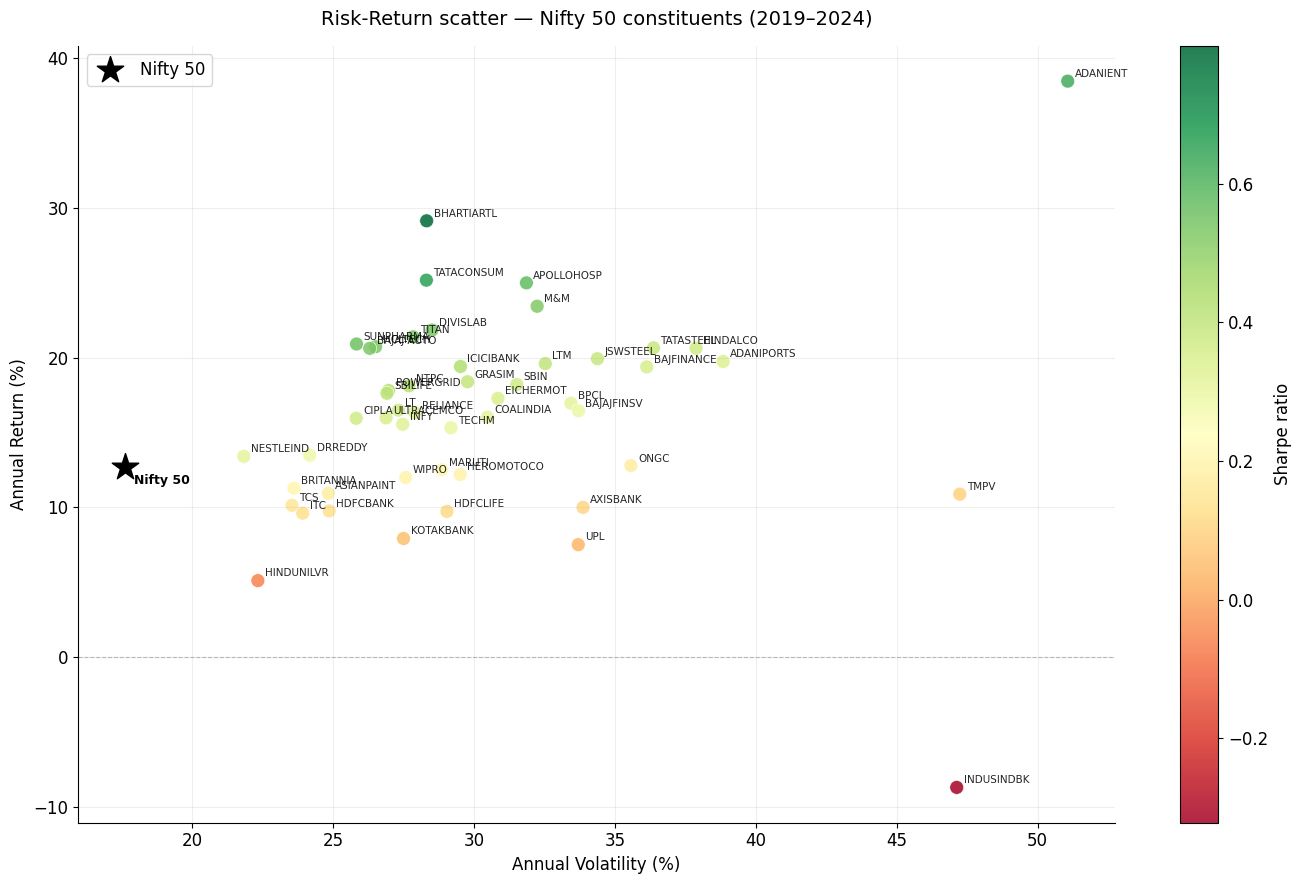

This scatter is the foundation for the efficient frontier in Phase 3.


In [38]:
# ── Cell 21: Risk-Return scatter plot ─────────────────────────────────────
# Classic finance chart — shows each stock's risk vs return tradeoff
# Stocks in the top-left quadrant are best (high return, low risk)
# This is the setup for the efficient frontier in Phase 3

fig, ax = plt.subplots(figsize=(14, 9))

scatter = ax.scatter(
    risk_metrics['Annual vol (%)'],
    risk_metrics['Annual return (%)'],
    c=risk_metrics['Sharpe ratio'],
    cmap='RdYlGn',
    s=100, alpha=0.85, edgecolors='white', linewidth=0.5
)

plt.colorbar(scatter, label='Sharpe ratio', ax=ax)

# Label each point
for ticker, row in risk_metrics.iterrows():
    ax.annotate(
        ticker,
        (row['Annual vol (%)'], row['Annual return (%)']),
        textcoords='offset points', xytext=(5, 3),
        fontsize=7.5, alpha=0.85
    )

# Add Nifty 50 benchmark point
bench_ret = benchmark_returns.mean() * TRADING_DAYS * 100
bench_vol = benchmark_returns.std() * np.sqrt(TRADING_DAYS) * 100
ax.scatter(bench_vol, bench_ret, marker='*', s=400, color='black', zorder=5, label='Nifty 50')
ax.annotate('Nifty 50', (bench_vol, bench_ret), xytext=(6, -12),
            textcoords='offset points', fontsize=9, fontweight='bold')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Annual Volatility (%)', fontsize=12)
ax.set_ylabel('Annual Return (%)', fontsize=12)
ax.set_title('Risk-Return scatter — Nifty 50 constituents (2019–2024)', fontsize=14, pad=15)
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('risk_return_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('This scatter is the foundation for the efficient frontier in Phase 3.')

In [39]:
# ── Cell 22: Save Phase 2 outputs ─────────────────────────────────────────

risk_metrics.to_csv(SAVE_PATH + 'risk_metrics.csv')
var_df.to_csv(SAVE_PATH + 'var_results.csv')

print('Phase 2 outputs saved:')
print(f'  risk_metrics.csv  — master risk table ({len(risk_metrics)} stocks)')
print(f'  var_results.csv   — VaR/CVaR results')
print()
print('=== Phase 2 complete ===')
print('Next: Phase 3 — Portfolio optimization & efficient frontier')

Phase 2 outputs saved:
  risk_metrics.csv  — master risk table (50 stocks)
  var_results.csv   — VaR/CVaR results

=== Phase 2 complete ===
Next: Phase 3 — Portfolio optimization & efficient frontier


---
## Phase 2 Summary — What you built

| Metric | What it measures | Interview relevance |
|---|---|---|
| Rolling vol | How risk changes over time | Always asked in risk roles |
| EWMA vol | Recent-weighted volatility | RiskMetrics / J.P. Morgan standard |
| Historical VaR | Empirical worst-case loss | Core risk management concept |
| Parametric VaR | Normal-distribution loss estimate | Asked in quant / FRM contexts |
| CVaR / ES | Average loss beyond VaR | Post-2008 regulatory standard |
| Max Drawdown | Peak-to-trough decline | Fund management interviews |
| Sharpe Ratio | Return per unit of total risk | Universal benchmark |
| Sortino Ratio | Return per unit of downside risk | More accurate than Sharpe |

**Next up — Phase 3:** Efficient frontier, Min Variance portfolio, Max Sharpe portfolio vs Nifty 50 benchmark.

---